## Ashwin
## School: SCDS

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVR, LinearSVR

In [ ]:
student_mat = pd.read_csv(r"C:\Users\Ashwin\Downloads\student+performance\student\student-mat.csv", sep=";")
student_mat.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Continued implementation...
pass


In [5]:
#Highly Correlated G2 helped in Increasing R2 Score
g2 = student_mat["G2"]
g3 = student_mat["G3"]
studytime=student_mat['studytime']


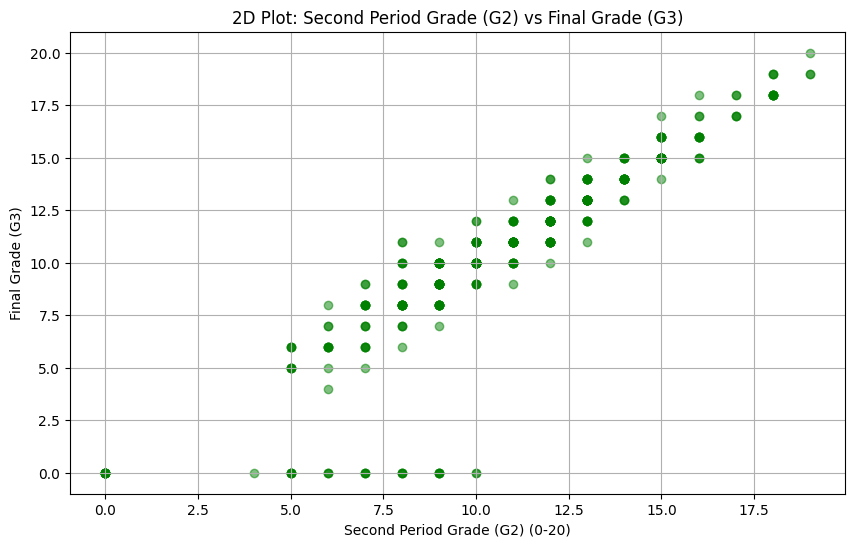

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(g2, g3, color='green', alpha=0.5)
plt.title("2D Plot: Second Period Grade (G2) vs Final Grade (G3)")
plt.xlabel("Second Period Grade (G2) (0-20)")
plt.ylabel("Final Grade (G3)")
plt.grid(True)
plt.show()

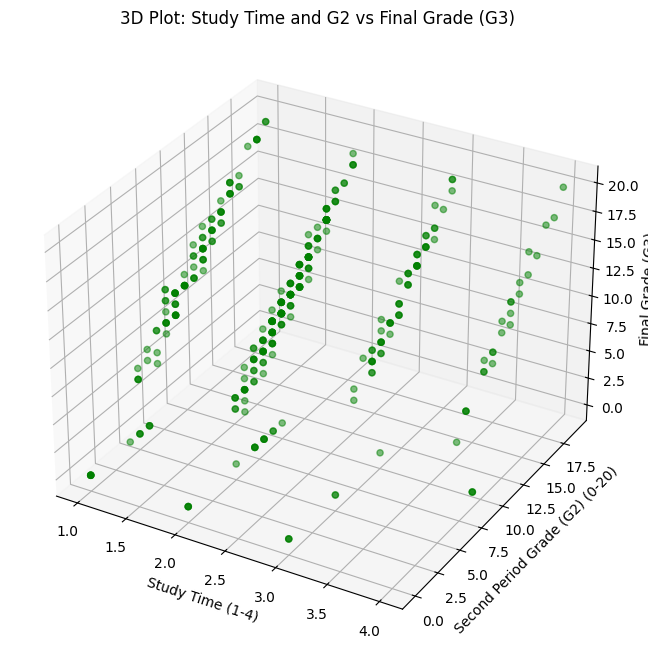

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(studytime, g2, g3, c='green', marker='o', alpha=0.5)
ax.set_title("3D Plot: Study Time and G2 vs Final Grade (G3)")
ax.set_xlabel("Study Time (1-4)")
ax.set_ylabel("Second Period Grade (G2) (0-20)")
ax.set_zlabel("Final Grade (G3)")
plt.show()

In [8]:
student_mat.drop(["school", "sex", "age", "address", "famsize", "Pstatus", "reason", 
                  "guardian", "famrel", "freetime", "Dalc", "Walc", "G1", 
                  "schoolsup", "famsup", "activities", "nursery", "higher", "internet", 
                  "romantic", "paid"], 
                 axis=1, inplace=True)

In [9]:
categorical_features = ["Mjob", "Fjob"]
numerical_features = ["Medu", "Fedu", "traveltime", "studytime", "failures", "goout", "health", "absences", "G2"]

In [10]:
ohe= OneHotEncoder(sparse_output=False, drop="first")
X_encoded = ohe.fit_transform(student_mat[categorical_features])

In [11]:
encoded_columns = ohe.get_feature_names_out(categorical_features)
encoded_columns

array(['Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher'],
      dtype=object)

In [12]:
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_columns)
X_encoded_df

,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
390,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
391,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
392,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
393,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [13]:
student_mat[numerical_features]

,Medu,Fedu,traveltime,studytime,failures,goout,health,absences,G2
0,4,4,2,2,0,4,3,6,6
1,1,1,1,2,0,3,3,4,5
2,1,1,1,2,3,2,3,10,8
3,4,2,1,3,0,2,5,2,14
4,3,3,1,2,0,2,5,4,10
...,...,...,...,...,...,...,...,...,...
390,2,2,1,2,2,4,4,11,9
391,3,1,2,1,0,5,2,3,16
392,1,1,1,1,3,3,3,3,8
393,3,2,3,1,0,1,5,0,12


In [14]:
X = pd.concat([X_encoded_df,student_mat[numerical_features]], axis=1)
y = student_mat["G3"]  # Target

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train

,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,Medu,Fedu,traveltime,studytime,failures,goout,health,absences,G2
181,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3,3,1,2,0,3,3,2,13
194,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,3,2,1,0,3,3,0,14
173,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,3,1,2,3,5,3,0,7
63,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,4,3,1,3,0,4,4,2,9
253,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,2,1,0,2,3,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,4,2,1,4,0,3,3,0,10
106,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,2,1,4,0,2,3,8,8
270,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3,3,1,2,2,5,5,15,9
348,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4,3,1,3,0,3,4,0,15


In [17]:
X_test

,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,Medu,Fedu,traveltime,studytime,failures,goout,health,absences,G2
78,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,2,1,3,1,3,2,8
371,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,2,3,1,0,3,3,3,12
248,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3,3,1,2,1,3,5,8,5
55,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1,1,2,0,4,2,8,9
390,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2,2,1,2,2,4,4,11,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,2,2,2,0,2,3,0,11
82,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3,2,1,2,0,4,5,10,6
114,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,1,1,2,0,2,5,8,9
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4,2,1,3,0,2,5,2,14


In [18]:
y_train

181    12
194    14
173     0
63      9
253     8
       ..
71     10
106     8
270     9
348    15
102    14
Name: G3, Length: 316, dtype: int64

In [19]:
y_test

78     10
371    12
248     5
55     10
390     9
       ..
364    12
82      6
114     9
3      15
18      5
Name: G3, Length: 79, dtype: int64

In [20]:
lr=LinearRegression()

In [21]:
lr.fit(X_train,y_train)

LinearRegression()

In [22]:
y_test

78     10
371    12
248     5
55     10
390     9
       ..
364    12
82      6
114     9
3      15
18      5
Name: G3, Length: 79, dtype: int64

In [23]:
# Print parameters

print(lr.intercept_)
print(lr.coef_)

-2.3100763613412276
[-0.44238873 -0.26414565  0.12769422  0.07718456  0.75794614  0.22579069
 -0.37641686  0.11398635  0.07386256 -0.14904191  0.20438052 -0.01401564
 -0.5294948   0.17039485  0.07761052  0.04029313  1.09729825]


In [24]:
y_pred = lr.predict(X_test)
y_pred

array([ 5.71871154, 11.72088591,  3.17875095,  8.86143083,  7.71913208,
       12.96844357, 18.53842789,  7.09232546,  7.79000257, 12.63164575,
       14.4712591 ,  6.78201581, 13.9777861 , 12.29206473, 14.5031431 ,
        6.80861758,  6.42827895, 10.85200217, 14.88443324,  8.98575982,
       13.72312149, 16.5933388 , 14.24832352,  5.62388158,  8.04101982,
       20.00584943, 10.46382477,  9.07137308, 17.26891723, 11.62246844,
        9.3540692 ,  7.86206851, 13.91487112, 12.79599058,  6.09107859,
        4.30879687, -2.50937126, 15.7501747 , 11.89148683,  7.59084793,
        4.42775672,  9.94965403, 14.29206588,  7.49103296, 15.47816277,
        9.33056507, 11.73607466, 14.15533409, 13.54853158, 15.34113505,
       12.86855864, 14.34374867,  9.5458729 ,  7.96958552,  4.73329702,
       13.50960162,  9.62793392,  6.52106328, 15.26512195, 15.63643275,
       14.07218074,  8.33289939,  7.0337376 ,  4.24206511,  5.10232654,
       16.55202021,  8.28929933,  9.07670343, 10.06747943, 15.65

In [25]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}") #without standard scaling

Mean Squared Error: 5.111716910212376
R² Score: 0.7507093330053806


In [26]:
scaler = StandardScaler() #With Standard Scaling
scaler

StandardScaler()

In [27]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
lr_scaled = LinearRegression()
lr_scaled

LinearRegression()

In [29]:
lr_scaled.fit(X_train_scaled, y_train)


LinearRegression()

In [30]:
y_pred_scaled = lr_scaled.predict(X_test_scaled)
print(y_pred_scaled)

[ 5.71871154 11.72088591  3.17875095  8.86143083  7.71913208 12.96844357
 18.53842789  7.09232546  7.79000257 12.63164575 14.4712591   6.78201581
 13.9777861  12.29206473 14.5031431   6.80861758  6.42827895 10.85200217
 14.88443324  8.98575982 13.72312149 16.5933388  14.24832352  5.62388158
  8.04101982 20.00584943 10.46382477  9.07137308 17.26891723 11.62246844
  9.3540692   7.86206851 13.91487112 12.79599058  6.09107859  4.30879687
 -2.50937126 15.7501747  11.89148683  7.59084793  4.42775672  9.94965403
 14.29206588  7.49103296 15.47816277  9.33056507 11.73607466 14.15533409
 13.54853158 15.34113505 12.86855864 14.34374867  9.5458729   7.96958552
  4.73329702 13.50960162  9.62793392  6.52106328 15.26512195 15.63643275
 14.07218074  8.33289939  7.0337376   4.24206511  5.10232654 16.55202021
  8.28929933  9.07670343 10.06747943 15.65932959  7.50581574  9.45753907
 13.05064736 19.68279412  9.84977161  6.19961443  7.97302206 13.20242208
  3.33779352]


In [31]:
r2_scaled = r2_score(y_test, y_pred_scaled)
print('The R² scores for Linear Regression are With Standard Scaling:',r2_scaled) #with standard scaling

The R² scores for Linear Regression are With Standard Scaling: 0.750709333005381


In [32]:
print('without scaling:',r2,'\n','with scaling :', r2_scaled)

without scaling: 0.7507093330053806 
 with scaling : 0.750709333005381


### Cross Validation
- Evaluate the robustness of model

In [33]:
from sklearn.model_selection import cross_val_score

scores_CV = cross_val_score(lr, X_train, y_train, cv=10)

print(scores_CV)

[0.80947648 0.84437226 0.89687965 0.83102693 0.78591037 0.8711572
 0.86907652 0.73299541 0.78036315 0.79521545]


In [34]:
print(scores_CV.mean())
print(scores_CV.std())

0.8216473419274868
0.047594650515783585


Cross validation score: 0.82 +/- 0.0475


### Cross Validation on entire dataset

In [35]:
from sklearn.model_selection import cross_val_score

scores_CV = cross_val_score(lr, X, y, cv=10)

print(scores_CV)

[0.86588746 0.8171226  0.95418261 0.84295948 0.79082062 0.88033749
 0.76927124 0.65300433 0.62787339 0.84573185]


In [36]:
print(scores_CV.mean())
print(scores_CV.std())

0.8047191059037031
0.09530937184874252


Cross validation score: 0.80 +/- 0.095

In [37]:
# SVM with Linear Kernel (optimized for speed)
from sklearn.model_selection import train_test_split, KFold, cross_val_score
svm_linear = LinearSVR(C=0.1, max_iter=1000, random_state=42)

In [38]:
# SVM with Linear Kernel (optimized for speed)
svm_linear = LinearSVR(C=0.1, max_iter=1000)

In [39]:
def evaluate_model(model, X_train, y_train, model_name):
    try:
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
        print(f"\n{model_name} K-Fold Cross-Validation R² Scores (5 folds):")
        print(f"R² Scores for each fold: {[round(score, 3) for score in cv_scores]}")
        print(f"Mean R² Score: {cv_scores.mean():.3f}")
        print(f"Standard Deviation of R² Scores: {cv_scores.std():.3f}")
        return cv_scores.mean()
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}")
        return None


In [40]:
svm_linear = LinearSVR(C=0.1, max_iter=1000)
svm_linear_r2 = evaluate_model(svm_linear, X_train, y_train, "SVM Linear Kernel")


SVM Linear Kernel K-Fold Cross-Validation R² Scores (5 folds):
R² Scores for each fold: [0.812, 0.789, 0.765, 0.918, 0.765]
Mean R² Score: 0.810
Standard Deviation of R² Scores: 0.057


In [41]:
svm_poly = SVR(kernel='poly', degree=3, C=0.1, cache_size=1000)
svm_poly_r2 = evaluate_model(svm_poly, X_train, y_train, "SVM Polynomial Kernel")


SVM Polynomial Kernel K-Fold Cross-Validation R² Scores (5 folds):
R² Scores for each fold: [0.446, 0.581, 0.573, 0.705, 0.532]
Mean R² Score: 0.567
Standard Deviation of R² Scores: 0.084


In [42]:
# SVM with RBF Kernel (optimized)
svm_rbf = SVR(kernel='rbf', C=0.1, gamma='scale', cache_size=1000)
svm_rbf_r2 = evaluate_model(svm_rbf, X_train, y_train, "SVM RBF Kernel")


SVM RBF Kernel K-Fold Cross-Validation R² Scores (5 folds):
R² Scores for each fold: [0.287, 0.382, 0.418, 0.427, 0.369]
Mean R² Score: 0.377
Standard Deviation of R² Scores: 0.050


In [43]:
svm_linear.fit(X_train_scaled, y_train)
svm_poly.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

SVR(C=0.1, cache_size=1000)

In [44]:
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

In [45]:
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_poly = mean_squared_error(y_test, y_pred_poly)
mse_rbf = mean_squared_error(y_test, y_pred_rbf)
print("MSE - Linear Kernel:", mse_linear)
print("MSE - Polynomial Kernel:", mse_poly)
print("MSE - RBF Kernel:", mse_rbf)

MSE - Linear Kernel: 4.448016645688949
MSE - Polynomial Kernel: 16.656535790551267
MSE - RBF Kernel: 16.793518395152926


In [46]:
from sklearn.metrics import r2_score
r2_linear = r2_score(y_test, y_pred_linear)
r2_poly = r2_score(y_test, y_pred_poly)
r2_rbf = r2_score(y_test, y_pred_rbf)
print("R² - Linear Kernel:", r2_linear)
print("R² - Polynomial Kernel:", r2_poly)
print("R² - RBF Kernel:", r2_rbf)

R² - Linear Kernel: 0.7830769864834125
R² - Polynomial Kernel: 0.18768605734980737
R² - RBF Kernel: 0.18100562385405095


In [47]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
# Train the model
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train, y_train)
# Predict
y_pred_tree = tree_reg.predict(X_test)
# Evaluate
mse_tree = mean_squared_error(y_test, y_pred_tree)
print("MSE - Decision Tree (max_depth=4):", mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print("R² - Decision Tree (max_depth=4):", r2_tree)

MSE - Decision Tree (max_depth=4): 4.585126051218066
R² - Decision Tree (max_depth=4): 0.7763903690990845


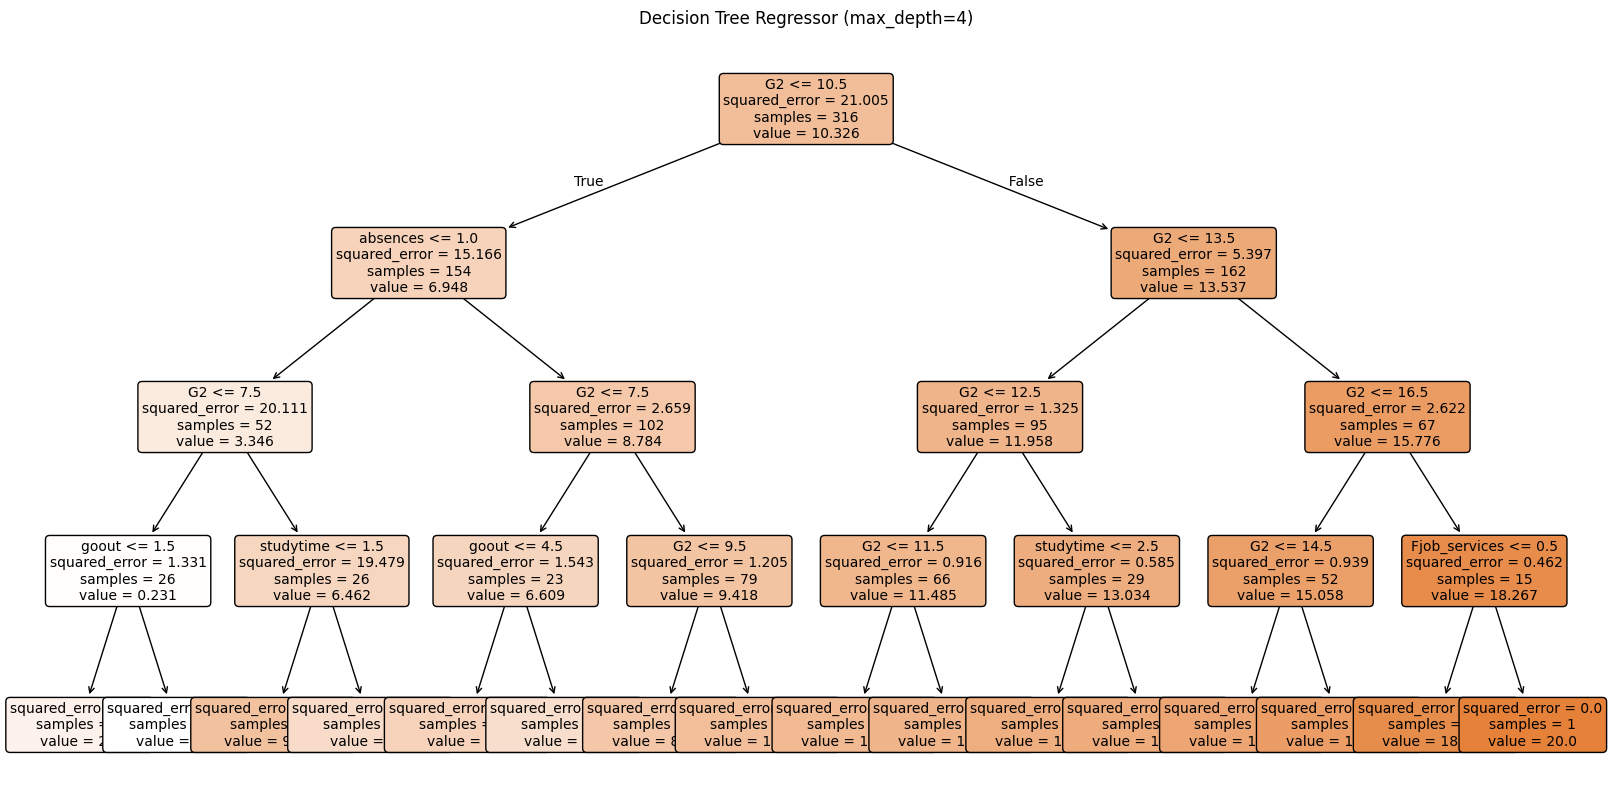

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Use feature names from X (if it's a DataFrame)
plt.figure(figsize=(20, 10))
plot_tree(tree_reg,
feature_names=X.columns, # <- this uses X directly
filled=True,
rounded=True,
fontsize=10)
plt.title("Decision Tree Regressor (max_depth=4)")
plt.show()

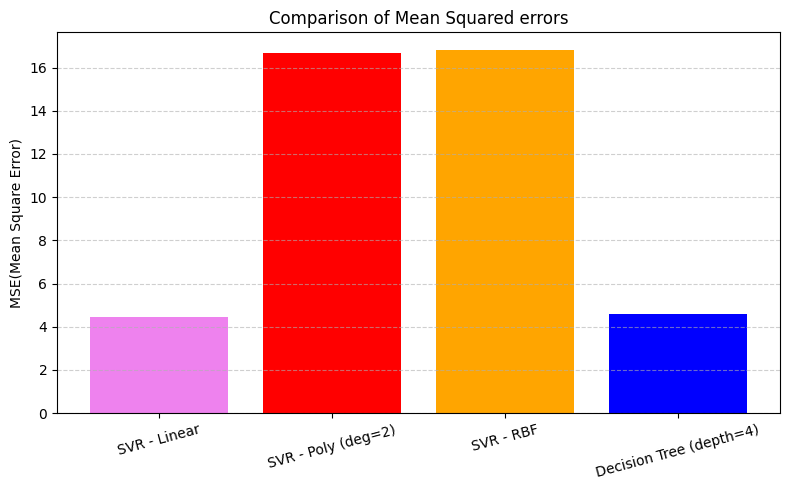

In [49]:
# Bar chart of MSEs
mse_values = [mse_linear, mse_poly, mse_rbf, mse_tree]
model_names = ['SVR - Linear', 'SVR - Poly (deg=2)', 'SVR - RBF', 'Decision Tree (depth=4)']

plt.figure(figsize=(8, 5))
plt.bar(model_names, mse_values, color=['violet', 'red', 'orange', 'blue'])
plt.title('Comparison of Mean Squared errors')
plt.ylabel('MSE(Mean Square Error)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Phase- III Course Project

In [50]:
from sklearn.svm import SVR
hyper_svm_reg=SVR(kernel='rbf')

## Lets try our own parameters

In [51]:
svr_reg_rbf=SVR(kernel='rbf',C=1,gamma=1)
svr_reg_rbf.fit(X_train_scaled,y_train)
score_svr_rbf=svr_reg_rbf.score(X_test_scaled,y_test)
print(score_svr_rbf)

0.021866604515987986


In [52]:
svr_reg_rbf=SVR(kernel='rbf',C=2,gamma=2)
svr_reg_rbf.fit(X_train_scaled,y_train)
score_svr_rbf=svr_reg_rbf.score(X_test_scaled,y_test)
print(score_svr_rbf)

0.014025451379355514


# Hyperparameter tuning of SVM Rbf kernel Using Grid Search

In [53]:
hpt_svm_svr=SVR(kernel='rbf')

In [54]:
# Define parameter grid
hpt_param_grid = {
    'C': list(range(1, 100)),               # C = 1 to 99
    'gamma': np.linspace(0.1, 1, 15)           # gamma values from 0.1 to 1 (15 evenly spaced values)
}
hpt_param_grid


{'C': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99],
 'gamma': array([0.1       , 0.16428571, 0.22857143, 0.29285714, 0.35714286,
        0.42142857, 0.48571429, 0.55      , 0.61428571, 0.67857143,
        0.74285714, 0.80714286, 0.87142857, 0.93571429, 1.        ])}

In [55]:
from sklearn.model_selection import GridSearchCV

In [56]:
grid_search=GridSearchCV(estimator=hpt_svm_svr,
                         param_grid=hpt_param_grid,
                         cv=5,
                         n_jobs=-1
                         )

In [57]:
grid_search.fit(X_train_scaled,y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                               15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
                               27, 28, 29, 30, ...],
                         'gamma': array([0.1       , 0.16428571, 0.22857143, 0.29285714, 0.35714286,
       0.42142857, 0.48571429, 0.55      , 0.61428571, 0.67857143,
       0.74285714, 0.80714286, 0.87142857, 0.93571429, 1.        ])})

In [58]:
best_params=grid_search.best_params_
print(best_params)

{'C': 10, 'gamma': 0.1}


In [59]:
best_model=grid_search.best_estimator_
print(best_model)

SVR(C=10, gamma=0.1)


In [60]:
score=grid_search.best_score_
print(grid_search.best_score_)

0.6605091181468208


In [61]:
y_pred_rbf= best_model.predict(X_test)
print(y_pred_rbf)

[9.69220617 9.67771419 9.67843779 9.67774967 9.67770143 9.67770305
 9.67770112 9.67770112 9.7493911  9.67770208 9.67770113 9.67818481
 9.67770118 9.67770869 9.67770112 9.70055242 9.68841812 9.67792321
 9.67770117 9.67847633 9.67770115 9.67770112 9.67770114 9.67903031
 9.67881773 9.67770112 9.67783565 9.6799826  9.67770112 9.67770148
 9.67770112 9.68165922 9.67770113 9.67770115 9.69365508 9.67769856
 9.67997641 9.67770112 9.67770989 9.67770112 9.6967962  9.6778373
 9.67770113 9.67775866 9.67770115 9.67903771 9.67770112 9.67770112
 9.67770113 9.67770112 9.67770124 9.67770117 9.67771587 9.67824449
 9.67797162 9.67770112 9.67850313 9.6899528  9.67770113 9.67770112
 9.67770115 9.6777137  9.67777683 9.70063029 9.68879965 9.67770112
 9.67843766 9.67840365 9.67770119 9.67770112 9.67772028 9.67890388
 9.67770112 9.67770112 9.67808084 9.6777236  9.6777225  9.67770115
 9.67770112]


c:\Users\Ashwin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


In [62]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [63]:
# View cross-validation results
cv_results = grid_search.cv_results_

In [64]:
results_df = pd.DataFrame(cv_results)
results_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.014894,0.003029,0.007345,0.001084,1,0.100000,"{'C': 1, 'gamma': 0.1}",0.369933,0.465262,0.519391,0.486623,0.439402,0.456122,0.050448,195
1,0.014394,0.002036,0.008476,0.000720,1,0.164286,"{'C': 1, 'gamma': 0.1642857142857143}",0.180679,0.283404,0.304198,0.291361,0.274846,0.266898,0.044179,389
2,0.018482,0.002698,0.007689,0.000761,1,0.228571,"{'C': 1, 'gamma': 0.2285714285714286}",0.079361,0.176361,0.171731,0.178368,0.172489,0.155662,0.038229,584
3,0.016655,0.002305,0.014343,0.012404,1,0.292857,"{'C': 1, 'gamma': 0.2928571428571429}",0.027178,0.117513,0.104275,0.117224,0.114084,0.096055,0.034772,778
4,0.013057,0.001557,0.010681,0.001534,1,0.357143,"{'C': 1, 'gamma': 0.3571428571428572}",-0.001781,0.082094,0.067419,0.083333,0.078948,0.062003,0.032384,972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,0.018206,0.001922,0.008033,0.001564,99,0.742857,"{'C': 99, 'gamma': 0.7428571428571429}",0.008464,0.095424,0.065072,0.081309,0.042589,0.058571,0.030606,974
1481,0.019245,0.002076,0.006555,0.000638,99,0.807143,"{'C': 99, 'gamma': 0.8071428571428572}",0.001361,0.082508,0.053791,0.069319,0.031259,0.047648,0.028753,1071
1482,0.017374,0.001835,0.007333,0.000913,99,0.871429,"{'C': 99, 'gamma': 0.8714285714285716}",-0.004040,0.071633,0.044573,0.059314,0.022665,0.038829,0.026936,1169
1483,0.019308,0.002904,0.008634,0.004382,99,0.935714,"{'C': 99, 'gamma': 0.9357142857142858}",-0.008195,0.062403,0.037007,0.050795,0.016206,0.031643,0.025168,1264


In [65]:
top_results = results_df.sort_values(by='mean_test_score',ascending=False)
#print(top_results[['param_C', 'param_gamma', 'mean_test_score','std_test_score','rank_test_score']]) # print top 10 results
df1=pd.DataFrame(top_results[['param_C', 'param_gamma', 'mean_test_score','std_test_score','rank_test_score']])
df1.tail(n=10)


,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
59,4,1.000000,0.002584,0.030313,1476
27,2,0.871429,0.002209,0.027392,1477
10,1,0.742857,0.001893,0.024113,1478
44,3,1.000000,-0.000423,0.028621,1479
11,1,0.807143,-0.001173,0.023383,1480
28,2,0.935714,-0.001244,0.026729,1481
12,1,0.871429,-0.003590,0.022805,1482
29,2,1.000000,-0.004049,0.026169,1483
13,1,0.935714,-0.005526,0.022344,1484
14,1,1.000000,-0.007089,0.021956,1485


In [66]:
# Print results
print(f"Best Hyperparameters: {best_params}")
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

Best Hyperparameters: {'C': 10, 'gamma': 0.1}
Mean Squared Error: 5.112
R² Score: 0.751


# Bagging - Random Forest Regressor

## Base model 

In [67]:
from sklearn.ensemble import RandomForestRegressor 
rf_reg=RandomForestRegressor(n_estimators=50, max_depth=25,n_jobs=-1,random_state=42)
rf_reg.fit(X_train_scaled,y_train)
score_reg=rf_reg.score(X_test_scaled,y_test)
print(score_reg)

0.8385466977151252


# Random Search on rbf kernel
Random Search is a tuning method that randomly samples combinations of hyperparameters from defined distributions. It is faster and more efficient than Grid Search, especially for large parameter spaces.

for random search the range is dictonary

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
param_dist = {
    'C': np.arange(1, 100),                    # C values from 1 to 100
    'gamma': np.linspace(0.1, 1, 15)           # gamma values from 0.1 to 1
}

In [70]:
param_dist

{'C': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
        86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
 'gamma': array([0.1       , 0.16428571, 0.22857143, 0.29285714, 0.35714286,
        0.42142857, 0.48571429, 0.55      , 0.61428571, 0.67857143,
        0.74285714, 0.80714286, 0.87142857, 0.93571429, 1.        ])}

In [71]:
# RandomizedSearchCV for SVR regression (RBF kernel)
random_search = RandomizedSearchCV(
    estimator=SVR(kernel='rbf'),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)

In [72]:
random_search.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=20, n_jobs=-1,
                   param_distributions={'C': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
                                        'gamma': array([0.1       , 0.16428571, 0.22857143, 0.29285714, 0.35714286,
       0.42142857, 0.48571429, 0.55      , 0.61428571, 0.67857143,
       0.74285714, 0.80714286, 0.87142857, 0.93571429, 1.        ])},
                   random_state=42, scoring='r2')

In [73]:
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)

Best parameters from RandomizedSearchCV: {'gamma': 0.1642857142857143, 'C': 6}


In [74]:
from sklearn.svm import SVR 
svr_reg=SVR(kernel='rbf'
            ,C=6
            ,gamma=0.16
    )
svr_reg.fit(X_train_scaled,y_train)
score_svr=svr_reg.score(X_test_scaled,y_test)
print(score_svr)

0.5523810561588507


## Applying hyperparametric tuning in Random forest - Grid Search

In [75]:
# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [10, 30, 50, 70, 100],
    'max_depth': [4, 8, 12, 16, 20, 25]
}

In [76]:
rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

In [77]:
rf_grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [4, 8, 12, 16, 20, 25],
                         'n_estimators': [10, 30, 50, 70, 100]},
             scoring='r2')

In [78]:
print("Best parameters:", rf_grid_search.best_params_)
print("Best cross-validated R² score:", rf_grid_search.best_score_)

Best parameters: {'max_depth': 16, 'n_estimators': 10}
Best cross-validated R² score: 0.8837961695239706


## Hypertuned model

In [79]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=10, max_depth=16, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)
score_rf_hpt = rf_reg.score(X_test_scaled, y_test)
print(score_rf_hpt)

0.8194331572531491


## Random Search on Random forest

In [80]:
from sklearn.model_selection import RandomizedSearchCV

In [81]:
# Define parameter distributions for RandomizedSearchCV
rf_param_dist = {
    'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'max_depth': [2, 4, 6, 8, 10, 12, 14]
}


In [82]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)


In [83]:
rf_random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [2, 4, 6, 8, 10, 12, 14],
                                        'n_estimators': [10, 20, 30, 40, 50, 60,
                                                         70, 80, 90, 100]},
                   random_state=42, scoring='r2')

In [84]:
print("Best parameters from RandomizedSearchCV:", rf_random_search.best_params_)
print("Best cross-validated R² score:", rf_random_search.best_score_)

Best parameters from RandomizedSearchCV: {'n_estimators': 10, 'max_depth': 8}
Best cross-validated R² score: 0.8820883335131997


# HyperTuned Model

In [85]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=10, max_depth=8, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)
score_rf_hpt = rf_reg.score(X_test_scaled, y_test)
print(score_rf_hpt)

0.8000361698968939


# Adaptive Boosting Base model

In [86]:
from sklearn.ensemble import AdaBoostRegressor

# Create and fit the AdaBoost regressor with default parameters
ada_reg = AdaBoostRegressor(random_state=42)
ada_reg.fit(X_train_scaled, y_train)

# Evaluate on test set
score_ada = ada_reg.score(X_test_scaled, y_test)
print("AdaBoost Regressor R² score:", score_ada)

AdaBoost Regressor R² score: 0.8412469614201897


## Hyperparametric tuning on Adaboost using decision tree stumps

In [89]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Define parameter grid for AdaBoost with decision tree stumps
ada_param_grid = {
    'n_estimators': [25, 50, 75, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeRegressor(max_depth=1)]
}

ada_grid_search = GridSearchCV(
    estimator=AdaBoostRegressor(random_state=42),
    param_grid=ada_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

ada_grid_search.fit(X_train_scaled, y_train)

print("Best parameters for AdaBoost:", ada_grid_search.best_params_)
print("Best cross-validated R² score:", ada_grid_search.best_score_)

Best parameters for AdaBoost: {'estimator': DecisionTreeRegressor(max_depth=1), 'learning_rate': 0.01, 'n_estimators': 75}
Best cross-validated R² score: 0.5371748544620927


In [88]:
ada_param_grid = {
    'n_estimators': [25, 50, 75, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeRegressor(max_depth=1)]
}

In [90]:
ada_grid_search = GridSearchCV(
    estimator=AdaBoostRegressor(random_state=42),
    param_grid=ada_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

In [ ]:
ada_grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=AdaBoostRegressor(random_state=42), n_jobs=-1,
             param_grid={'estimator': [DecisionTreeRegressor(max_depth=1)],
                         'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
                         'n_estimators': [25, 50, 75, 100, 150]},
             scoring='r2')

In [ ]:
print("Best parameters for AdaBoost:", ada_grid_search.best_params_)
print("Best cross-validated R² score:", ada_grid_search.best_score_)

Best parameters for AdaBoost: {'estimator': DecisionTreeRegressor(max_depth=1), 'learning_rate': 0.01, 'n_estimators': 75}
Best cross-validated R² score: 0.5371748544620927


## Hypertuned Model on Adaboosting

In [91]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=75, max_depth=1, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)
score_rf_hpt = rf_reg.score(X_test_scaled, y_test)
print(score_rf_hpt)

0.645479126859409


## Random Search for Adaboosting

In [92]:
ada_param_dist = {
    'n_estimators': [25, 50, 75, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'estimator': [DecisionTreeRegressor(max_depth=1)]
}


In [93]:
ada_random_search = RandomizedSearchCV(
    estimator=AdaBoostRegressor(random_state=42),
    param_distributions=ada_param_dist,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)


In [95]:
ada_random_search.fit(X_train_scaled, y_train)


RandomizedSearchCV(cv=5, estimator=AdaBoostRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'estimator': [DecisionTreeRegressor(max_depth=1)],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.5,
                                                          1.0],
                                        'n_estimators': [25, 50, 75, 100, 150]},
                   random_state=42, scoring='r2')

In [96]:
print("Best parameters from RandomizedSearchCV:", ada_random_search.best_params_)
print("Best cross-validated R² score:", ada_random_search.best_score_)

Best parameters from RandomizedSearchCV: {'n_estimators': 50, 'learning_rate': 0.01, 'estimator': DecisionTreeRegressor(max_depth=1)}
Best cross-validated R² score: 0.5319824188372728


## Gradient Boosting on Grid Search

In [97]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV


In [98]:
# Define parameter grid for Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5]
}


In [99]:
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)


In [100]:
gb_grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'max_depth': [2, 3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='r2')

In [101]:
print("Best parameters for Gradient Boosting:", gb_grid_search.best_params_)
print("Best cross-validated R² score:", gb_grid_search.best_score_)

Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best cross-validated R² score: 0.8781451626032653


## Hypertuned Model on Gradient Boosting

In [102]:
# Train GradientBoostingRegressor with best hyperparameters from grid search
gb_best = GradientBoostingRegressor(
    n_estimators=gb_grid_search.best_params_['n_estimators'],
    learning_rate=gb_grid_search.best_params_['learning_rate'],
    max_depth=gb_grid_search.best_params_['max_depth'],
    random_state=42
)
gb_best.fit(X_train_scaled, y_train)
score_gb_hpt = gb_best.score(X_test_scaled, y_test)
print("Hypertuned Gradient Boosting R² score:", score_gb_hpt)

Hypertuned Gradient Boosting R² score: 0.847247665532225


## Apply Random Search for Gradient boosting

In [103]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [104]:
# Define parameter distributions for RandomizedSearchCV
gb_param_dist = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5]
}

In [105]:
gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    random_state=42
)

In [106]:
gb_random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'n_estimators': [50, 100, 150]},
                   random_state=42, scoring='r2')

In [107]:
print("Best parameters from RandomizedSearchCV:", gb_random_search.best_params_)
print("Best cross-validated R² score:", gb_random_search.best_score_)

Best parameters from RandomizedSearchCV: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1}
Best cross-validated R² score: 0.8765774559409852


In [108]:
# Continued implementation...
pass


In [110]:
# Collect and print the final R² scores for all models
final_scores = {
    "Linear Regression (with scaling)": r2_scaled,
    "SVR - Linear Kernel": r2_linear,
    "SVR - Polynomial Kernel": r2_poly,
    "SVR - RBF Kernel": r2_rbf,
    "SVR - RBF Kernel (GridSearchCV best)": r2,  # r2 from grid search evaluation
    "Random Forest (Base)": score_reg,
    "Random Forest (GridSearchCV best)": score_rf_hpt,
    "AdaBoost (Base)": score_ada,
    "Gradient Boosting (GridSearchCV best)": gb_grid_search.best_score_,
}

print("Final R² Scores for All Models:")
for model, score in final_scores.items():
    print(f"{model}: {score:.4f}")

Final R² Scores for All Models:
Linear Regression (with scaling): 0.7507
SVR - Linear Kernel: 0.7831
SVR - Polynomial Kernel: 0.1877
SVR - RBF Kernel: 0.1810
SVR - RBF Kernel (GridSearchCV best): 0.7507
Random Forest (Base): 0.8385
Random Forest (GridSearchCV best): 0.6455
AdaBoost (Base): 0.8412
Gradient Boosting (GridSearchCV best): 0.8781


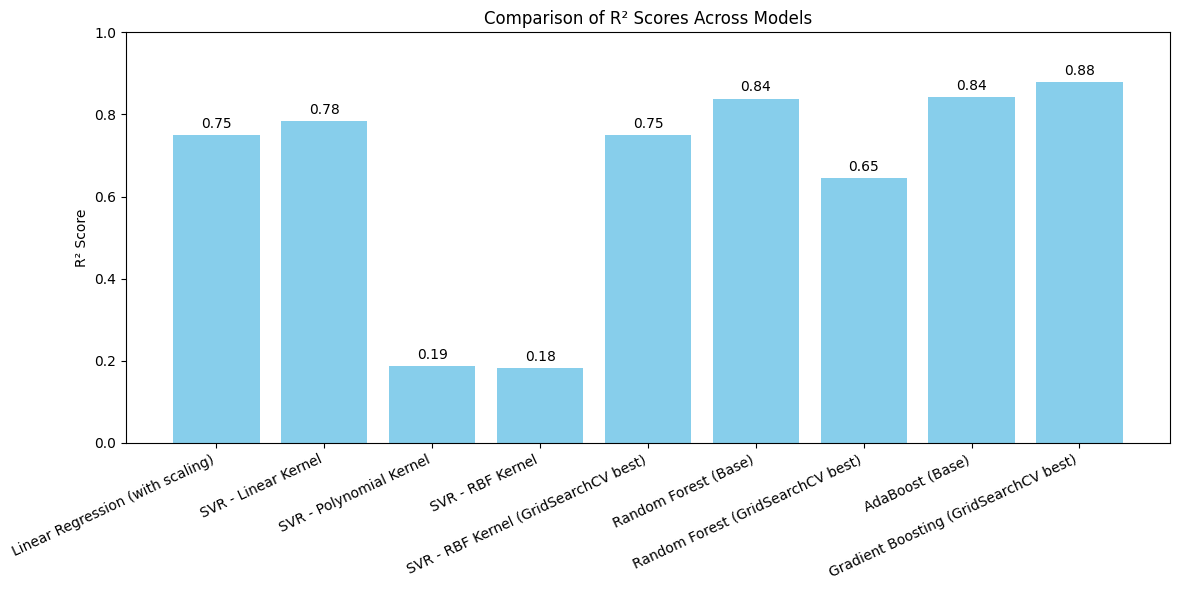

In [111]:
import matplotlib.pyplot as plt

# Prepare model names and their R² scores for plotting
model_names = list(final_scores.keys())
scores = list(final_scores.values())

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, scores, color='skyblue')
plt.ylabel('R² Score')
plt.title('Comparison of R² Scores Across Models')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)

# Annotate bars with their values
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{score:.2f}", 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()